In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq
# from evcouplings.align import Alignment

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
# from validation_stats import *
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

df_rif = pd.read_csv(os.path.join(data_path, "RIF/data_for_model.csv"))
df_rif_val = pd.read_csv(os.path.join(data_path, "RIF/validation_data_for_model.csv"))

df_mxf = pd.read_csv(os.path.join(data_path, "MXF/data_for_model.csv"))
df_mxf_val = pd.read_csv(os.path.join(data_path, "MXF/validation_data_for_model.csv"))

RIF_isolate_variants = pd.read_csv(os.path.join(data_path, "RIF/rpoBC_variants_10543isolates.csv"))
MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF/gyrBA_variants_8569isolates.csv"))

coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

if len(solo_results) == 1:
    solo_results = solo_results[list(solo_results.keys())[0]]

# Three Additional Sources of Data to Test On:

## 1. MIC-ML: Currently still running through pipeline to get VCF files
## 2. TRUST: Prospective analysis, data coming in, but they haven't been phenotypically tested yet
## 3. WHO: Ask Tim Rodwell if we can use their data

In [2]:
# MIC_ML = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/MIC_ML_consortium_MIC_table.csv")

# MIC_ML.rename(columns={"MOXI_quality": "MXF_quality", "MOXI_lower_bound": "MXF_lower_bound", "MOXI_midpoint": "MXF_midpoint", "MOXI_upper_bound": "MXF_upper_bound"}, inplace=True)

In [3]:
def process_bounds_MICML_data(df, drug):
    
    df_single_drug = df.loc[~pd.isnull(df[f"{drug}_midpoint"])]
    new_dfs = []
    
    for db in df_single_drug["DB_OF_ORIGIN"].unique():
        
        df_single_db = df_single_drug.query("DB_OF_ORIGIN==@db").reset_index(drop=True)
        
        lower, midpoint, upper = df_single_db[[f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]].values.T
        db_bounds = list(np.sort(np.unique(np.concatenate([lower, midpoint, upper]))))
        print(db, db_bounds)
        
        for i, row in df_single_db.iterrows():
            
            if (row[f"{drug}_lower_bound"] == row[f"{drug}_midpoint"]) or (row[f"{drug}_upper_bound"] == row[f"{drug}_midpoint"]):
                
                # set the midpoint to the second smallest value
                if row[f"{drug}_midpoint"] == 0:
                    midpoint_idx = 1
                else:
                    midpoint_idx = db_bounds.index(row[f"{drug}_midpoint"])
                
                # the recorded value is the upper bound
                new_high = db_bounds[midpoint_idx]
                
                # if the upper bound is the smallest concentration, the lower bound should be 0
                if midpoint_idx == 0:
                    new_low = 0 #db_bounds[midpoint_idx]
                # the lower bound should be 1 concentration below the upper bound
                else:
                    new_low = db_bounds[midpoint_idx-1]
                
                df_single_db.loc[i, [f"{drug}_lower_bound", f"{drug}_upper_bound", f"{drug}_midpoint"]] = [new_low, new_high, np.mean([new_low, new_high])]
                
        new_dfs.append(df_single_db)
    
    df_final = pd.concat(new_dfs, axis=0)
    assert len(df_final) == len(df_single_drug)
    assert len(set(df_final["ROLLINGDB_ID"]).symmetric_difference(df_single_drug["ROLLINGDB_ID"])) == 0
    
    cols = ['ID', 'BIOSAMPLE_ACCESSION', 'ROLLINGDB_ID', 'ISOLATION_LOCATION',
       'DB_OF_ORIGIN', 'STUDY_NAME', 'STUDY_PMID', 'TESTING_LOCATION', 'MEDIA']
    return df_final[cols + [f"{drug}_quality", f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]]

In [4]:
# df_mxf = process_bounds_MICML_data(MIC_ML, "MXF")


In [5]:
# df_rif = process_bounds_MICML_data(MIC_ML, "RIF")


In [6]:
drug = "Rifampicin"
RIF_catalog_stats = pd.read_csv(f"{drug}/validation/catalog_stats.csv")

RIF_Reg_stats = pd.read_csv(f"{drug}/validation/Reg_stats.csv")
RIF_Reg_stats["Without_1Bin"] = 1 - RIF_Reg_stats["Within_1Bin"]

RIF_CNN_stats = pd.read_csv(f"{drug}/validation/CNN_stats.csv")
RIF_CNN_stats["Without_1Bin"] = 1 - RIF_CNN_stats["Within_1Bin"]

In [7]:
def plot_catplot(catalog_stats, reg_stats, cnn_stats, variable_lst, lower_bounds=None, upper_bounds=None, 
                 error_bars=False, label_padding=0, sharey=False, kind="bar", percent=False, sigfig=2, saveName=None
                ):
    
    binary_metrics_for_plotting = pd.concat([catalog_stats.melt(id_vars=['Model', 'Dataset', 'CV']).query("variable in @variable_lst"),
                                  reg_stats.melt(id_vars=['Model', 'Dataset', 'CV']).query("variable in @variable_lst"),
                                  cnn_stats.melt(id_vars=['Model', 'Dataset', 'CV']).query("variable in @variable_lst")
                                 ], axis=0)
        
    if percent:
        binary_metrics_for_plotting["value"] *= 100
    
    # binary_metrics_for_plotting = stats_all_models.query("CV == 0")

    palette = sns.color_palette("Set2")
    palette = palette.as_hex()
    
    # quantitative metrics only, so no Catalog classification
    color_dict = dict(zip(["CNN", "Regression", "Catalog"], palette[:len(binary_metrics_for_plotting["Model"].unique())]))

    if len(binary_metrics_for_plotting["Model"].unique()) == 3:
        hue_order = ["Catalog", "Regression", "CNN"]
    else:
        hue_order = ["Regression", "CNN"]
        
    if error_bars:
        error_bars = ("pi", 95)
        # binary_metrics_for_plotting = binary_metrics_for_plotting.query("CV > 0")
    else:
        error_bars = None
        binary_metrics_for_plotting = binary_metrics_for_plotting.query("CV == 0")
        
    g = sns.catplot(data=binary_metrics_for_plotting.query("variable in @variable_lst"), 
                    x="Dataset", 
                    y="value", 
                    hue="Model", 
                    col="variable", 
                    col_order=variable_lst,
                    col_wrap=3,
                    hue_order=hue_order,
                    kind=kind, 
                    aspect=1, 
                    height=4, 
                    palette=color_dict,
                    errorbar=error_bars,
                    edgecolor="black",
                    linewidth=0.5,
                    errwidth=0.75,
                    capsize=0.05,
                    sharex=False,
                    sharey=sharey,
                    legend_out=True
                   )
            
    if type(lower_bounds) == list and type(upper_bounds) == list:
        for i in range(len(lower_bounds)):
            if lower_bounds[i] is not None and upper_bounds[i] is not None:
                g.axes.flat[i].set(ylim=(lower_bounds[i], upper_bounds[i]))

    if kind == "bar":
        for ax in g.axes.flat:
            for i in range(len(ax.containers)):
                
                # larger font when there are fewer bars
                if len(hue_order) == 2:
                    size = 9
                else:
                    size = 7
                    
                ax.bar_label(ax.containers[i], fmt=f"%.{sigfig}f", fontsize=size, label_type="center", padding=label_padding)

    g.set_titles(template='{col_name}\n')
    g.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

# Rifampicin

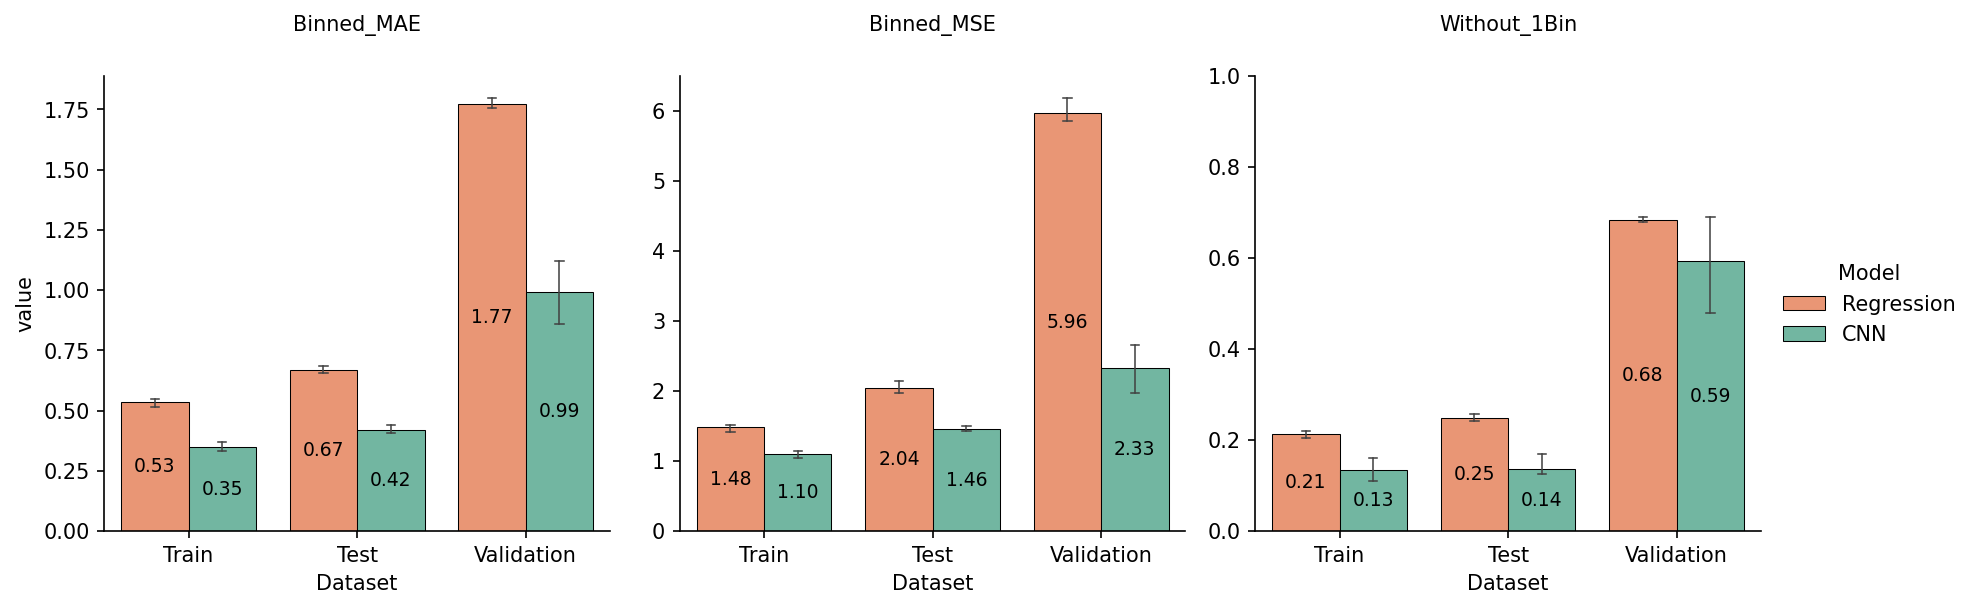

In [8]:
# variable_lst = ['Sensitivity', 'Specificity', 'AUC', 'Accuracy']
variable_lst = ['Binned_MAE', 'Binned_MSE', "Without_1Bin"]
sharey = False

plot_catplot(RIF_catalog_stats, RIF_Reg_stats, RIF_CNN_stats, variable_lst, 
             lower_bounds=[None, None, 0], upper_bounds=[None, None, 1], 
             error_bars = True, sharey=sharey, kind="bar", percent=False, sigfig=2,
             #saveName="Rifampicin/validation/quantitative_metrics_errorBars.png"
            )

In [10]:
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    
    print(variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        catalog_mean = RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable].mean()
        cnn_mean = RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable].mean()
        
        if catalog_mean > cnn_mean:
            alt = "greater"
        else:
            alt = "less"
        
        pval = st.mannwhitneyu(RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable],
                              RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                              alternative="two-sided",
                                )[1]
        
        if pval < 0.05:
            pval = st.mannwhitneyu(RIF_catalog_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  alternative=alt,
                                    )[1]
            print(f"   {dataset} catalog is {alt}, {pval}")
        else:
            print(f"   {dataset} catalog is ns, {pval}")

Sensitivity
   Validation catalog is less, 0.0013775955446953152
Specificity
   Validation catalog is ns, 0.09823728105632684
Balanced_Acc
   Validation catalog is less, 0.012790648078739504


In [46]:
variable_lst = ["Sensitivity", "Specificity", "Balanced_Acc"]

for variable in variable_lst:
    
    print(variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        reg_mean = RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable].mean()
        cnn_mean = RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable].mean()
        
        if reg_mean > cnn_mean:
            alt = "greater"
        else:
            alt = "less"
        
        pval = st.mannwhitneyu(RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable],
                              RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                              alternative="two-sided"
                                )[1]
        
        if pval < 0.05:
            pval = st.mannwhitneyu(RIF_Reg_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  RIF_CNN_stats.query("Dataset==@dataset & CV > 0")[variable],
                                  alternative=alt
                                    )[1]
            print(f"   {dataset} regression is {alt}, {pval}")

Sensitivity
   Validation regression is less, 8.681851696007563e-05
Specificity
   Validation regression is greater, 6.427544906448233e-05
Balanced_Acc
   Validation regression is less, 8.981125249535405e-05


In [39]:
df = RIF_catalog_stats.copy()

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
        lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
        lower = np.round(lower * 100, 1)
        upper = np.round(upper * 100, 1)
        
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
93.9: (92.8, 95.6)

Specificity
93.1: (90.9, 94.4)

Balanced_Acc
93.5: (92.2, 94.8)


In [38]:
df = RIF_CNN_stats.copy()

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
        lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
        lower = np.round(lower * 100, 1)
        upper = np.round(upper * 100, 1)
        
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
95.5: (95.2, 95.8)

Specificity
92.7: (92.6, 92.8)

Balanced_Acc
94.1: (94.0, 94.3)


In [40]:
df = RIF_Reg_stats.copy()

for variable in variable_lst:
    print("\n" + variable)
    #for dataset in RIF_catalog_stats.Dataset.unique():
    for dataset in ["Validation"]:
        
        mean = np.round(df.query("Dataset==@dataset & CV > 0")[variable].mean() * 100, 1)
        lower, upper = np.percentile(df.query("Dataset==@dataset & CV > 0")[variable], q = [2.5, 97.5])
        lower = np.round(lower * 100, 1)
        upper = np.round(upper * 100, 1)
        bbb
        print(f"{mean}: ({lower}, {upper})")


Sensitivity
85.6: (82.9, 87.3)

Specificity
98.0: (97.6, 98.3)

Balanced_Acc
91.8: (90.3, 92.8)


In [20]:
# # variable_lst = ['Sensitivity', 'Specificity', 'AUC', 'Accuracy']
# variable_lst = ['Binned_MAE', 'Binned_MSE', "Without_1Bin"]
# sharey = False

# plot_catplot(RIF_catalog_stats, RIF_Reg_stats, RIF_CNN_stats, variable_lst, lower_bounds=[None, None, 0], upper_bounds=[None, None, 1], 
#              error_bars = False, sharey=sharey, kind="bar", percent=False, sigfig=2,
#              saveName="Rifampicin/validation/quantitative_metrics.png"
#             )

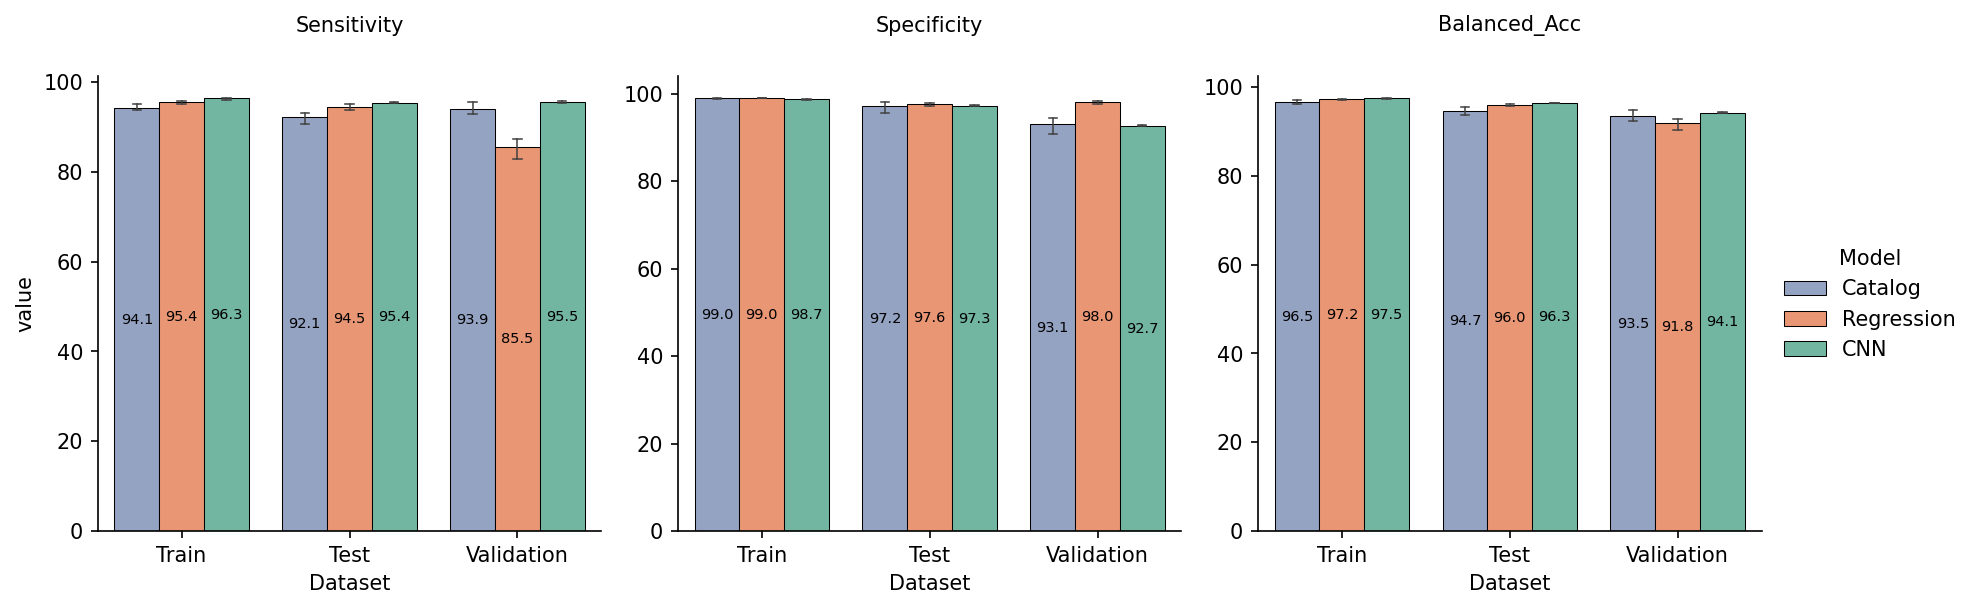

In [19]:
variable_lst = ['Sensitivity', 'Specificity', 'Balanced_Acc']
sharey = False

plot_catplot(RIF_catalog_stats, RIF_Reg_stats, RIF_CNN_stats, variable_lst, lower_bounds=None, upper_bounds=None, 
             error_bars = True, sharey=sharey, kind="bar", percent=True, sigfig=1,
             saveName="Rifampicin/validation/binary_metrics_errorBars.png"
            )

In [21]:
# variable_lst = ['Sensitivity', 'Specificity', 'Balanced_Acc']
# sharey = False

# plot_catplot(RIF_catalog_stats, RIF_Reg_stats, RIF_CNN_stats, variable_lst, lower_bounds=None, upper_bounds=None, sharey=sharey, kind="bar", 
#              error_bars = False, percent=True, sigfig=1, saveName="Rifampicin/validation/binary_metrics.png"
#             )

# Moxifloxacin

In [33]:
drug = "Moxifloxacin"
MXF_catalog_stats = pd.read_csv(f"{drug}/validation/catalog_stats.csv")

MXF_Reg_stats = pd.read_csv(f"{drug}/validation/Reg_stats.csv")
MXF_Reg_stats["Without_1Bin"] = 1 - MXF_Reg_stats["Within_1Bin"]

MXF_CNN_stats = pd.read_csv(f"{drug}/validation/CNN_stats.csv")
MXF_CNN_stats["Without_1Bin"] = 1 - MXF_CNN_stats["Within_1Bin"]

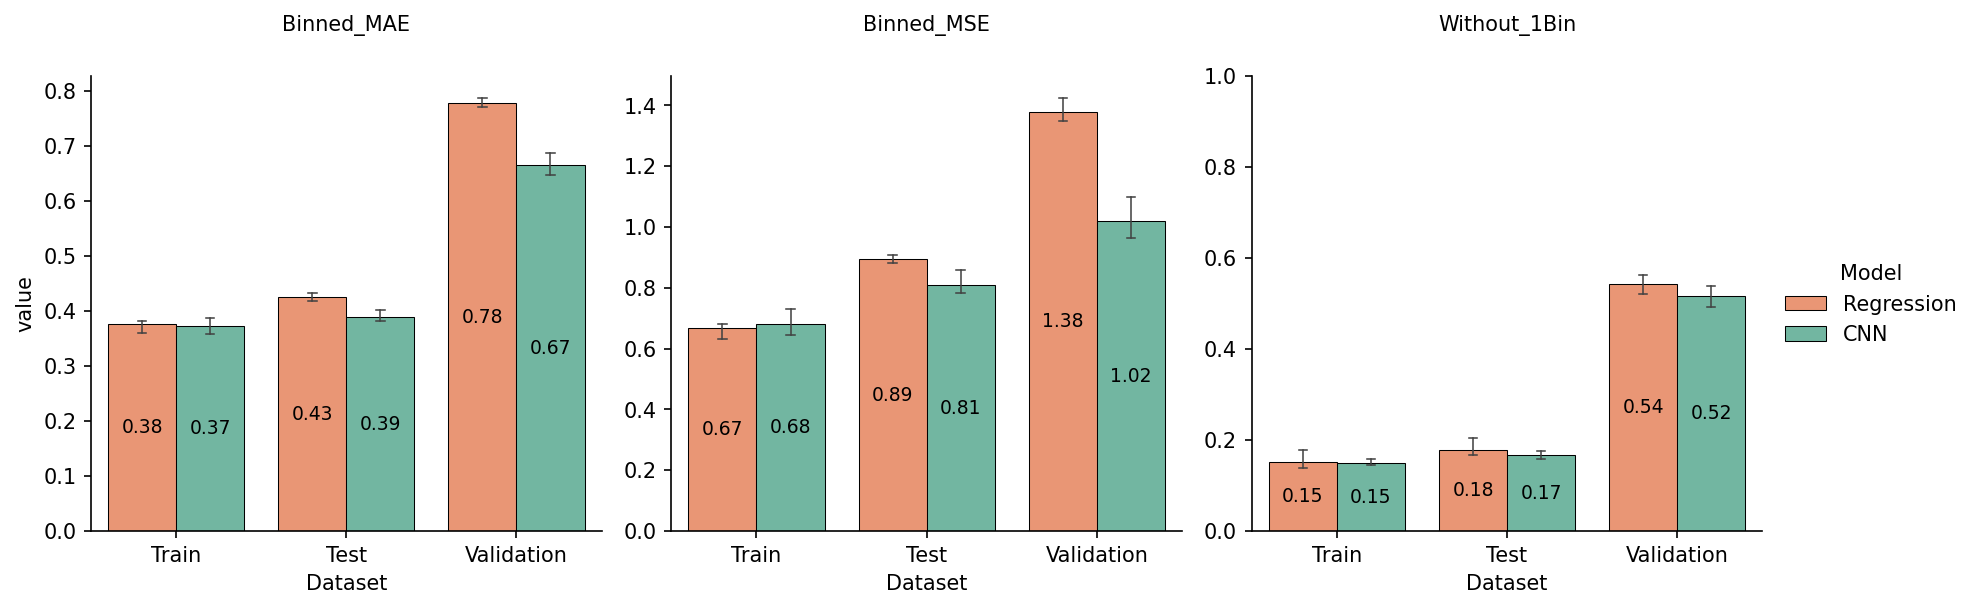

In [36]:
# variable_lst = ['Sensitivity', 'Specificity', 'AUC', 'Accuracy']
variable_lst = ['Binned_MAE', 'Binned_MSE', "Without_1Bin"]
sharey = False

plot_catplot(MXF_catalog_stats, MXF_Reg_stats, MXF_CNN_stats, variable_lst, 
             lower_bounds=[None, None, 0], upper_bounds=[None, None, 1], 
             error_bars = True, sharey=sharey, kind="bar", percent=False, sigfig=2,
             saveName="Moxifloxacin/validation/quantitative_metrics_errorBars.png"
            )

In [65]:
var = "Binned_MSE"

st.mannwhitneyu(MXF_Reg_stats.query("Dataset=='Test' & CV > 0")[var],
                MXF_CNN_stats.query("Dataset=='Test' & CV > 0")[var],
                alternative='greater'
               )

MannwhitneyuResult(statistic=100.0, pvalue=9.133589555477501e-05)

In [72]:
def test_for_significance(x1, x2, var, alt="two-sided"):
    
    assert sum(~pd.isnull(x1.query("CV>0 & Dataset=='Test'")[var].values)) == sum(~pd.isnull(x2.query("CV>0 & Dataset=='Test'")[var].values))
    return st.mannwhitneyu(x1.query("CV>0 & Dataset=='Test'")[var], x2.query("CV>0 & Dataset=='Test'")[var], alternative=alt)[1]

In [73]:
test_for_significance(MXF_Reg_stats, MXF_CNN_stats, "Binned_MSE")

0.00018267179110955002

In [76]:
var = "Binned_MSE"

st.mannwhitneyu(MXF_Reg_stats.query("CV>0 & Dataset=='Test'")[var],
                MXF_CNN_stats.query("CV>0 & Dataset=='Test'")[var],
                alternative='two-sided'
               )

MannwhitneyuResult(statistic=100.0, pvalue=0.00018267179110955002)

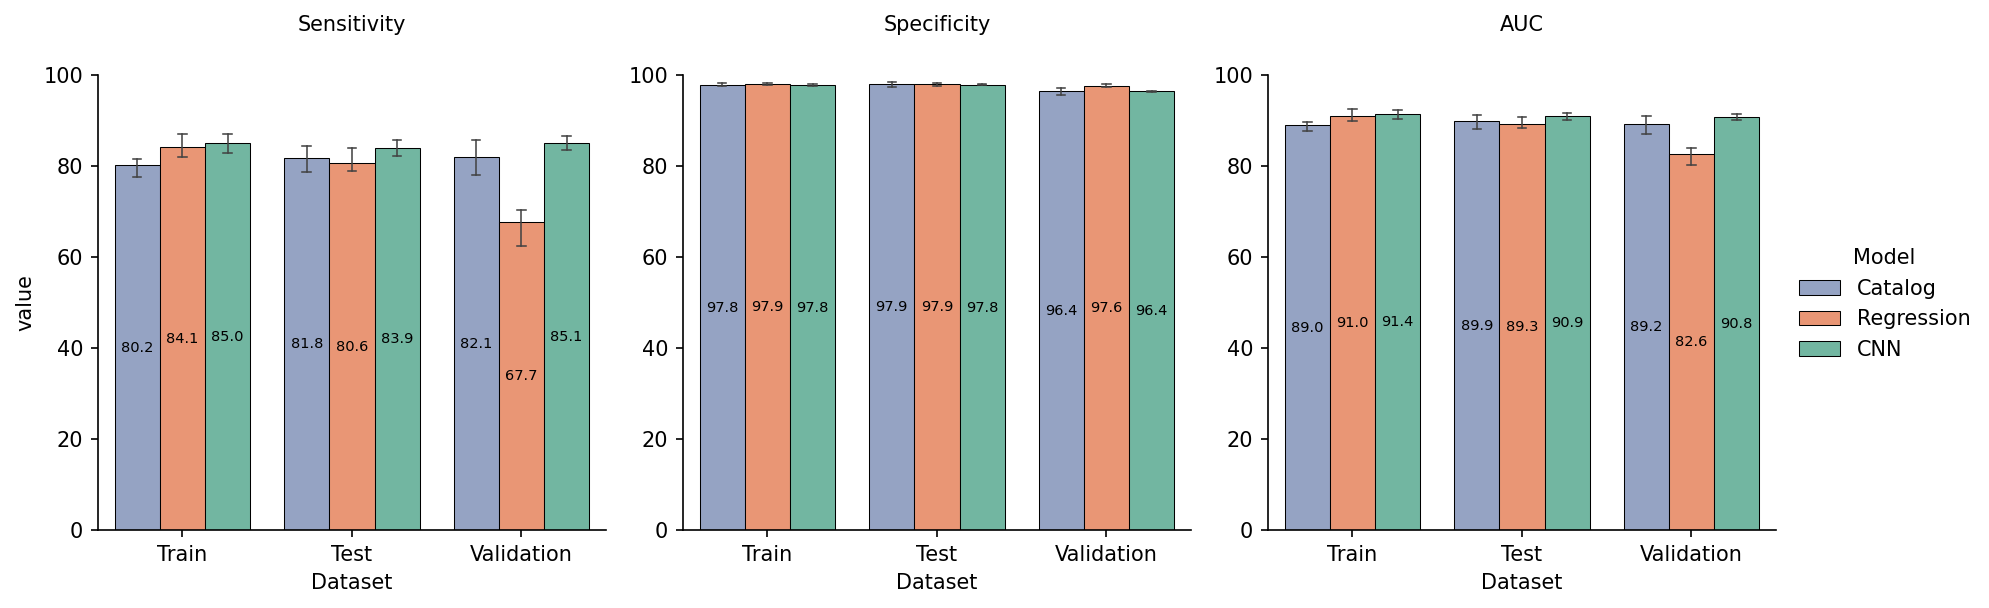

In [46]:
variable_lst = ['Sensitivity', 'Specificity', 'AUC']
sharey = False

plot_catplot(MXF_catalog_stats, MXF_Reg_stats, MXF_CNN_stats, variable_lst, lower_bounds=[0, 0, 0], upper_bounds=[100, 100, 100], 
             error_bars = True, sharey=sharey, kind="bar", percent=True, sigfig=1,
             saveName="Moxifloxacin/validation/binary_metrics_errorBars.png"
            )

In [3]:
def plot_actual_predicted_MIC(df, pred_col="y_pred", actual_col="y_test", mode=1, saveName=None):
    
    min_val = np.min([df[pred_col], df[actual_col]]) * 0.95
    # min_val = -5
    # max_val = 3
    
    if mode == 1:
        
        max_val = np.max([df[pred_col], df[actual_col]]) * 1.05
        
        fig, ax = plt.subplots(figsize=(5, 4))

        values = np.vstack([df[pred_col], df[actual_col]])
        kernel = st.gaussian_kde(values)(values)

        sns.scatterplot(
            data=df,
            x=pred_col,
            y=actual_col,
            c=kernel,
            #hue="pred_diff",
            cmap="Blues",
            linewidth=0.25,
            edgecolor="lightgray",
            ax=ax
        )
        
        ax.set_xlabel("Predicted MIC (µg/mL)")
        ax.set_ylabel("Actual MIC (µg/mL)")
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.set_xticks(ticks=ax.get_xticks(), labels=np.round(2**ax.get_xticks(), 2))
        ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(2**ax.get_yticks(), 2))

    else:
        
        max_val = np.max([df[pred_col], df[actual_col]]) * 1.2
        
        g = sns.JointGrid(data=df, x=pred_col, y=actual_col, space=0)
        g.plot_joint(sns.kdeplot,
                     fill=True, #clip=((2200, 6800), (10, 25)),
                     thresh=0, levels=100, cmap="Blues")

        g.plot_marginals(sns.histplot, color="#1f77b4", alpha=1, bins=len(np.unique(df[actual_col])))

        g.ax_joint.set_xlabel("\nPredicted MIC (µg/mL)")
        g.ax_joint.set_ylabel("Actual MIC (µg/mL)\n")
        g.ax_joint.set_xlim(min_val, max_val)
        g.ax_joint.set_ylim(min_val, max_val)

        g.ax_joint.set_xticks(ticks=g.ax_joint.get_xticks(), labels=np.round(2**g.ax_joint.get_xticks(), 2))
        g.ax_joint.set_yticks(ticks=g.ax_joint.get_yticks(), labels=np.round(2**g.ax_joint.get_yticks(), 2))

    # g = sns.jointplot(
    #     data=df, x=pred_col, y=actual_col,
    #     kind="kde",
    # )
    
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300)
    else:
        plt.show()

In [34]:
plot_actual_predicted_MIC(df_RIF_CNN_predictions.query("Dataset=='validation'"), saveName="Rifampicin/validation/CNN_predictions.png")


NameError: name 'df_RIF_CNN_predictions' is not defined

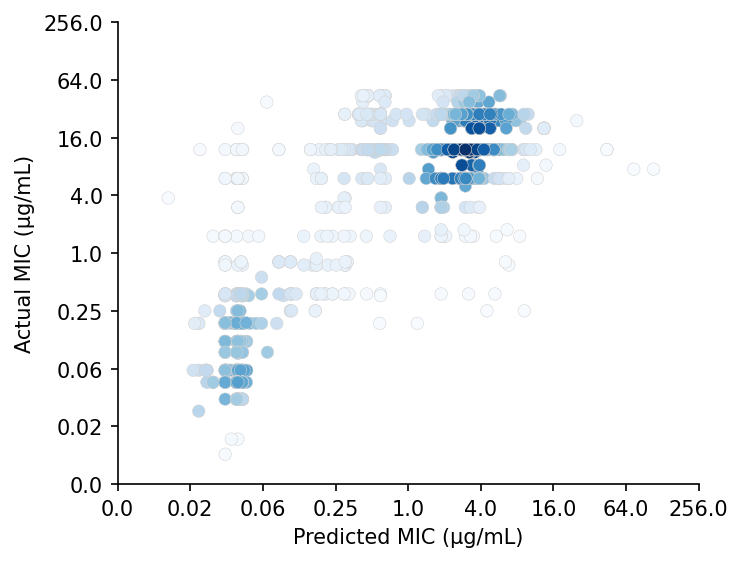

In [25]:
plot_actual_predicted_MIC(df_RIF_Reg_predictions.query("Dataset=='validation'"))



# TRUST Additional Validation Data

## Compare CNN and Regression Predictions?

In [19]:
df_trust_patients = pd.read_csv("TRUST_data_20230417.csv")
# df_trust_patients["patient_num"] = [int(patient_id.replace("T0", "")) for patient_id in df_trust_patients["pid"].values]

# trust_report = pd.read_excel("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/2023-01-24_report_Farhat.v09.xlsx", sheet_name=None)
# print(trust_report.keys())

df_trust_combined = pd.read_csv("TRUST_combined_samples_patients.csv")
df_trust_combined.rename(columns={"Coll2014": "Coll2014_Annotated"}, inplace=True)
df_trust_combined["Coll2014"] = [val.split(" ")[0] for val in df_trust_combined["Coll2014_Annotated"].values]
df_trust_combined["Lineage"] = [val[0] if val[0].isnumeric() else val for val in df_trust_combined["Coll2014"].values]




In [20]:
df_trust_patients.columns

Index(['pid', 'screen_version', 'screen_date', 'screen_ic', 'screen_icdate',
       'screen_parentic___1', 'screen_reenroll', 'screen_prevpid',
       'screen_sex', 'screen_race',
       ...
       'lca', 'fib4', 'prevtb_trt_time', 'TBtrt_diff_time', 'prevtb_age',
       'prevtb_outcome', 'total_adherence', 'adherence_12week',
       'first_dots_date', 'last_dots_date'],
      dtype='object', length=6573)

In [21]:
df_trust_patients

,pid,screen_version,screen_date,screen_ic,screen_icdate,screen_parentic___1,screen_reenroll,screen_prevpid,screen_sex,screen_race,...,lca,fib4,prevtb_trt_time,TBtrt_diff_time,prevtb_age,prevtb_outcome,total_adherence,adherence_12week,first_dots_date,last_dots_date
0,T0004,NaN,0,1,0,0,NaN,NaN,1,1,...,2.0,0.796894,NaN,NaN,NaN,1.0,0.910256,1.000000,1,225
1,T0007,NaN,0,1,0,0,NaN,NaN,2,1,...,1.0,0.706331,NaN,NaN,NaN,2.0,0.977444,1.000000,4,194
2,T0008,NaN,0,1,0,0,NaN,NaN,1,1,...,1.0,0.313172,NaN,NaN,NaN,NaN,0.962121,1.000000,3,192
3,T0013,NaN,0,1,0,0,NaN,NaN,2,1,...,3.0,0.935029,NaN,NaN,NaN,2.0,0.861111,0.967213,1,205
4,T0018,NaN,0,1,0,0,NaN,NaN,2,1,...,1.0,0.442371,NaN,NaN,NaN,NaN,0.850000,1.000000,1,202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,T0266,13.0,0,1,0,1,0.0,NaN,2,1,...,2.0,0.207970,NaN,NaN,NaN,NaN,0.971223,1.000000,3,200
113,T0268,13.0,0,1,0,0,0.0,NaN,2,1,...,3.0,0.436449,NaN,NaN,NaN,NaN,0.983333,0.983333,5,175
114,T0269,13.0,0,1,0,0,0.0,NaN,1,1,...,1.0,0.233620,NaN,NaN,NaN,1.0,0.975410,1.000000,7,181
115,T0270,13.0,0,1,0,0,0.0,NaN,1,1,...,1.0,0.232028,NaN,NaN,NaN,NaN,0.887097,0.881356,6,182


In [4]:
rpoBC = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/rpoBC.fasta", "fasta")]
rpoBC_TRUST = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/TRUST/rpoBC.fasta", "fasta")]

# yay, no alignment changes
len(rpoBC[0][1]), len(rpoBC_TRUST[0][1])

(7826, 7826)

In [5]:
gyrBA = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas/gyrBA.fasta", "fasta")]
gyrBA_TRUST = [(seq.id, seq.seq) for seq in SeqIO.parse("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/TRUST/gyrBA.fasta", "fasta")]

# yay, no alignment changes
len(gyrBA[0][1]), len(gyrBA_TRUST[0][1])

(4832, 4832)

In [6]:
X_rpoBC_TRUST = get_new_aln_for_regression(df_trust_combined["SampleID"].values,
                                           ["rpoBC"],
                                           "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC",
                                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/TRUST"
                                          )


KeyboardInterrupt



In [ ]:
X_rpoBC_TRUST.shape

In [11]:
def get_validation_predictions(drug, 
                              locus_list, 
                              config_file,
                              isolates_lst,
                              trust_dir
                             ):

    # load in previously trained model
    kwargs = yaml.safe_load(open(config_file, "r"))
    filter_size = kwargs["filter_size"]
    N_epochs = kwargs["N_epochs"]
    BATCH_SIZE = kwargs["batch_size"]

    output_path = kwargs["output_path"]
    binary_thresh = kwargs["binary_thresh"]
    loss_type = kwargs["loss_type"]
    binary = kwargs["binary"]
    bounded_loss = kwargs["bounded_loss"]

    # insilico validation doesn't make much sense to include lineages, unless you want to see how each lineage is predicted
    df_genos = make_genotype_df(locus_list, trust_dir)
    df_genos = df_genos.loc[isolates_lst]

    # Apply one-hot encoding function to get each isolate sequence
    print('making one hot encoding for...')
    for locus in locus_list:
        print("...", locus)
        lengths = [len(seq) for seq in df_genos[locus]]
        assert len(np.unique(lengths)) == 1
        df_genos[f"{locus}_one_hot"] = df_genos[locus].apply(np.vectorize(get_one_hot))

    # if not os.path.isfile(os.path.join(trust_dir, "pkl_sparse_data.npz")):
    X = create_X(df_genos)

    # get longest locus from the pickle file
    X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz'))

    # shape = 1 x 5 x longest_locus x num_loci
    longest_locus = X_h37rv.shape[2]
    num_loci = X_h37rv.shape[-1]
    del X_h37rv

    num_lineages = 0
    best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
    best_model.load_weights(os.path.join(output_path, "best_model.h5"))

    # X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
    predicted_mics = best_model.predict([X, np.zeros(X.shape[0]), np.zeros(X.shape[0])], batch_size=BATCH_SIZE).flatten()
    df_genos[f"{drug}_log_MIC_CNN"] = predicted_mics
    
    for locus in locus_list:
        del df_genos[locus]
        del df_genos[f"{locus}_one_hot"]
        
    df_genos[f"{drug}_MIC_CNN"] = np.exp2(df_genos[f"{drug}_log_MIC_CNN"])
    return df_genos.reset_index().rename(columns={"index":"SampleID"})

In [12]:
isolates_lst = df_trust_combined.query("comment=='-'")["SampleID"].values
print(len(isolates_lst))

RIF_TRUST_pred = get_validation_predictions("RIF",
                                           ["rpoBC"],
                                           "../config_rif.yaml",
                                           isolates_lst,
                                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/TRUST"
                                          )

df_trust_combined = df_trust_combined.merge(RIF_TRUST_pred, on="SampleID")

193
1 loci!
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/TRUST/rpoBC.fasta
making one hot encoding for...
... rpoBC
found 1 genes and longest gene 7826


2023-05-05 15:54:47.242580: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-05-05 15:54:47.242661: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-05-05 15:54:47.242700: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (compute-f-17-13.o2.rc.hms.harvard.edu): /proc/driver/nvidia/version does not exist


Fitting quantitative model
2/2 [==============================] - 9s 3s/step


In [13]:
isolates_lst = df_trust_combined.query("comment=='-'")["SampleID"].values
print(len(isolates_lst))

MXF_TRUST_pred = get_validation_predictions("MXF",
                                           ["gyrBA"],
                                           "../config_mxf.yaml",
                                           isolates_lst,
                                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/TRUST"
                                          )

df_trust_combined = df_trust_combined.merge(MXF_TRUST_pred, on="SampleID")



193
1 loci!
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/TRUST/gyrBA.fasta
making one hot encoding for...
... gyrBA
found 1 genes and longest gene 4832
Fitting quantitative model
2/2 [==============================] - 5s 2s/step


In [16]:
df_trust_combined.groupby("Coll2014")[["RIF_MIC_CNN", "MXF_MIC_CNN"]].mean()



,RIF_MIC_CNN,MXF_MIC_CNN
Coll2014,,
2.2.1,0.049603,0.070850
2.2.1.1,0.049640,0.070845
3,0.054143,0.067866
3.1.1,0.054177,0.070850
4.1.1.1,0.063591,0.070760
4.1.1.3,0.062062,0.070850
4.1.2.1,0.059395,0.070850
4.2.2,0.057130,0.071349
4.3.2.1,0.054700,0.101379


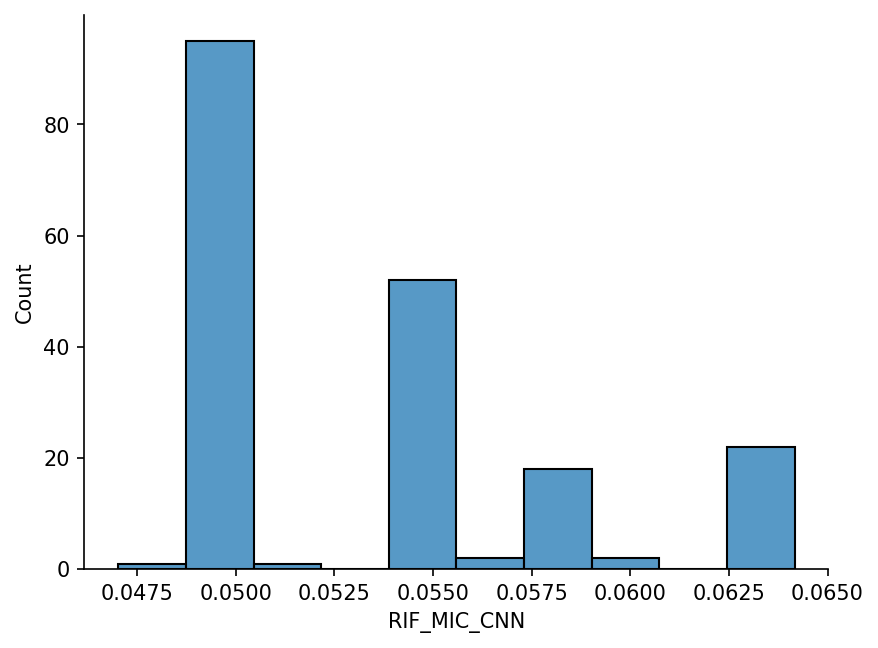

In [17]:
sns.histplot(df_trust_combined["RIF_MIC_CNN"])
sns.despine()
plt.show()



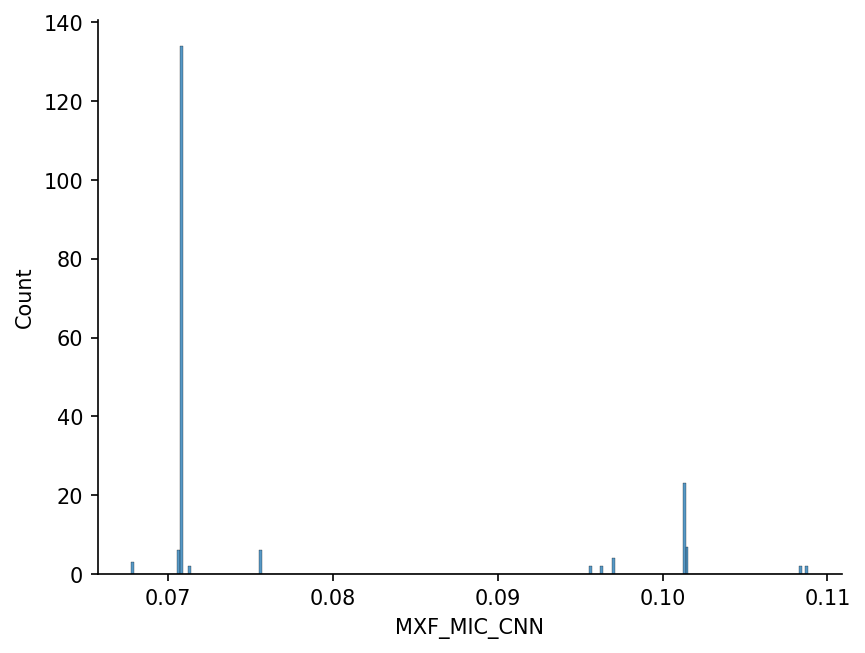

In [18]:
sns.histplot(df_trust_combined["MXF_MIC_CNN"])
sns.despine()
plt.show()

In [13]:
# df_trust_samples = trust_report['summary'].reset_index(drop=True)

# df_trust_samples.rename(columns={"original ID": "original_ID", 
#                                  "phylogenetic classification (Coll et al., 2014)": "Coll2014", 
#                                  "Cov Any Mean": "Cov_Any_Mean",
#                                  "Cov Unam Perc": "Cov_Unam_Perc",
#                                  "Perc. Reads Mapped": "Perc_Reads_Mapped"
#                                 }, inplace=True)

# for i, row in df_trust_samples.iterrows():
    
#     if row["original_ID"][:2] != 'S0':
#         df_trust_samples.loc[i, "original_ID"] = "S0" + row["original_ID"]
        
# df_trust_samples["patient_num"] = [int(sample_id.split("-")[0].replace("S0", "")) for sample_id in df_trust_samples["original_ID"].values]
# df_trust_samples["sample_week"] = [sample_id.split("-")[1].replace("S0", "") for sample_id in df_trust_samples["original_ID"].values]

# # keep only patients that are in both dataframes. If they don't have a sample, we can't do anything with it. But actually merging left or inner give the same results
# df_trust_combined = df_trust_patients[["pid", "patient_num"]].merge(df_trust_samples, on="patient_num", how="inner").reset_index(drop=True)

# seq_sample_paths = list(set(glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/221216.TRUST.Illumina.Batch2.Output/*")).union(glob.glob("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/220617.TRUST.Set1.Illumina.Output/*")))
# seq_sample_IDs = np.array([os.path.basename(path) for path in seq_sample_paths])

# seq_sample_dict = dict(zip(seq_sample_IDs, seq_sample_paths))

# for i, row in df_trust_combined.iterrows():
    
#     sample_id = row["SampleID"]
    
#     if sample_id in seq_sample_dict.keys():
        
#         seq_dir = seq_sample_dict[sample_id]
#         vcf_file = os.path.join(seq_dir, f"IlluminaWGS/Pilon_IlluminaPE_AlignedTo_H37rv_minMQ_1_minDP_5_Fix_All_Breaks/{sample_id}.IllPE.H37rv.vcf.gz")
        
#         if os.path.isfile(vcf_file):
#             df_trust_combined.loc[i, "VCF"] = vcf_file
#         else:
#             print(sample_id)
            
# assert len(df_trust_combined.loc[pd.isnull(df_trust_combined["VCF"])]) == 0
# df_trust_combined.to_csv("TRUST_combined_samples_patients.csv", index=False)

In [37]:
df_trust_combined[["SampleID", "VCF"]].to_csv("../data_processing/TRUST_paths.csv", index=False)

In [40]:
pd.Series(glob.glob("/n/scratch3/users/s/sak0914/TRUST_VCF/*")).to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/samples_lst.txt", sep="\t", index=False, header=None)

In [1]:
df_trust_combined

NameError: name 'df_trust_combined' is not defined